In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.thesis_plots import *
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [12]:
pickles = [
    '../../NR37/multiblock/Output/NASAR37.pik',
    '../../HECC/multiblock/Output/NASA_HECC.pik',
]

data = []
for pik in pickles:
    with open(pik, 'rb') as f:
        data.append(pickle.load(f))

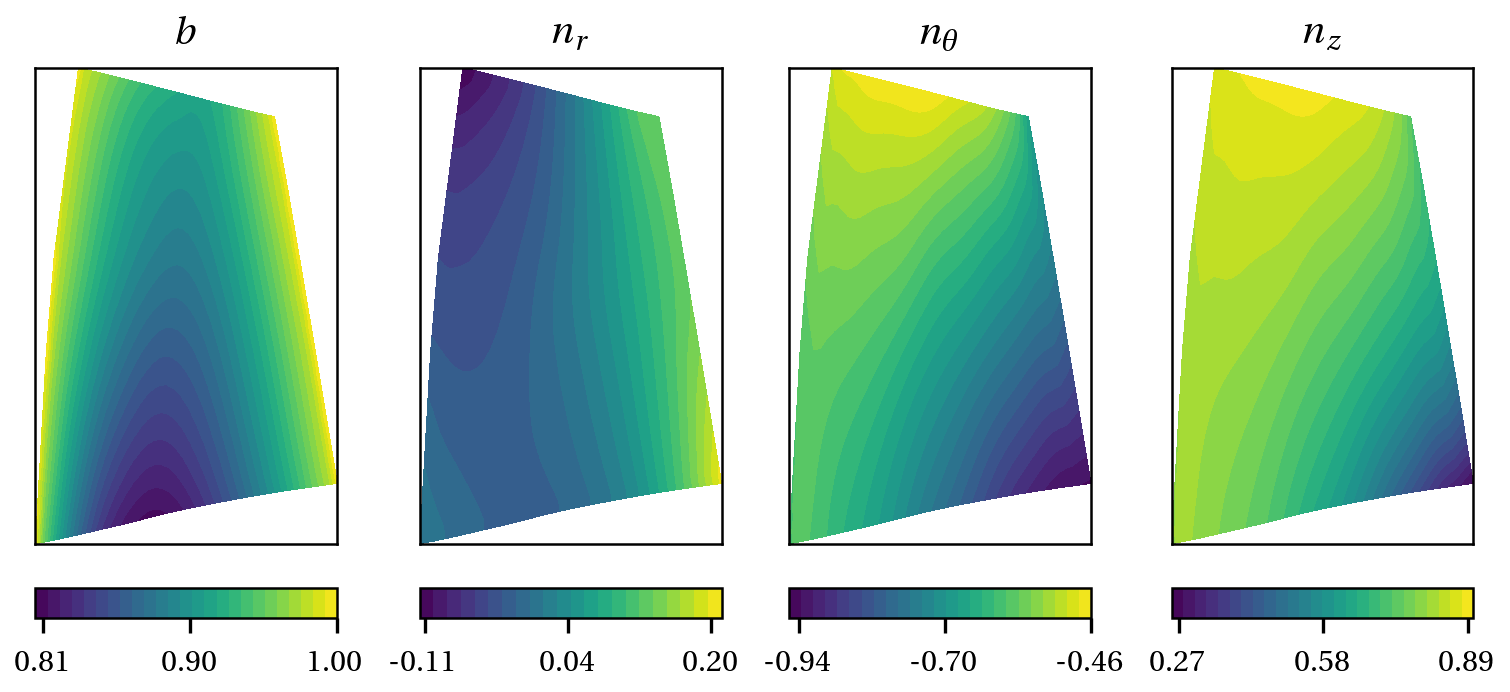

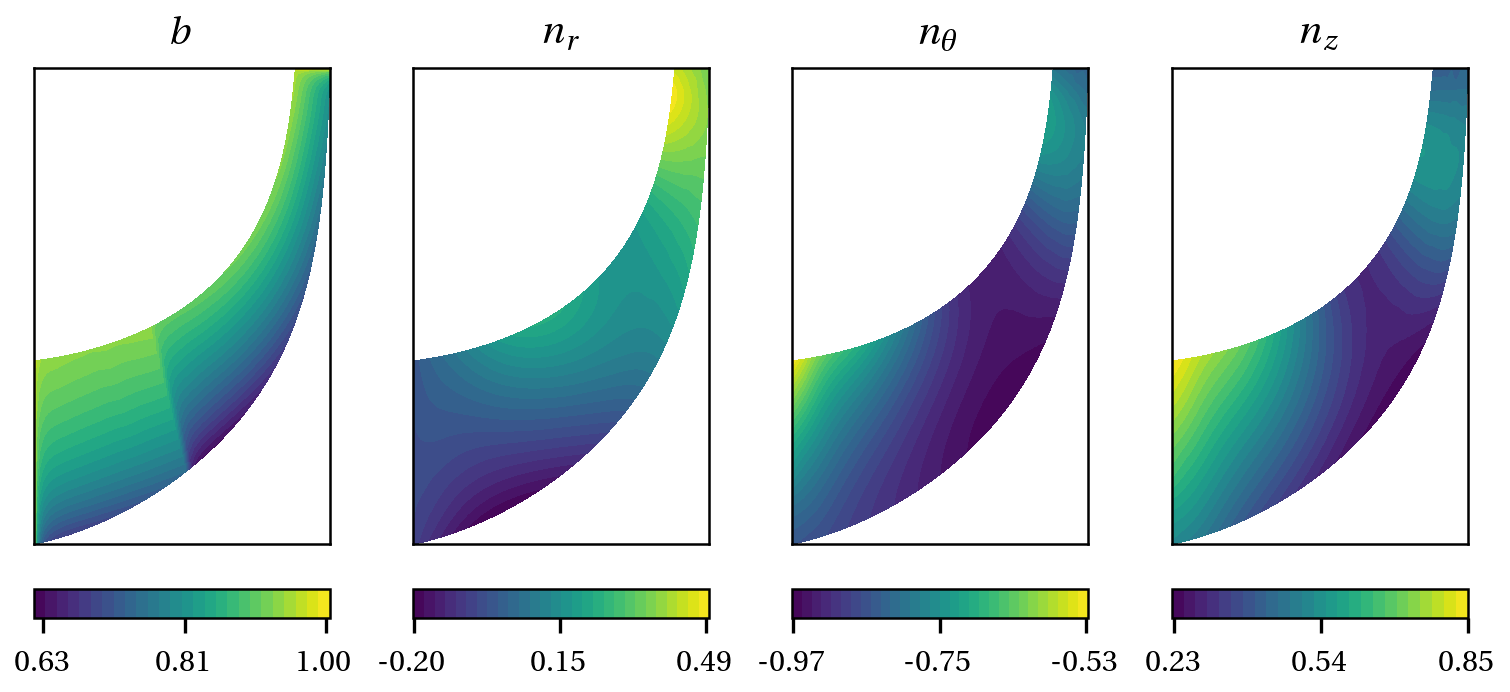

In [13]:
set_thesis_style()
levs = 30

for imachine, machine in enumerate(data):
    fig, ax = create_figure(fraction=1.0, aspect_ratio=0.55, subplots=(1,4))
    blade = machine.multiBlockGrid.blades[0]
    rgrid = blade.r_grid
    zgrid = blade.z_grid
    blockage = blade.blockage
    nr = blade.n_camber_r
    nt = blade.n_camber_t
    nz = blade.n_camber_z
    
    titles = [
        r'$b$',
        r'$n_r$',
        r'$n_{\theta}$',
        r'$n_z$'
    ]
    
    for axi, data, title in zip(ax, [blockage, nr, nt, nz], titles):

        cf = axi.contourf(zgrid, rgrid, data, cmap='viridis', levels=levs)
        cbar = fig.colorbar(cf, ax=axi, orientation='horizontal', location='bottom', pad=0.08, aspect=10)
        # cbar = fig.colorbar(cf, ax=axi, orientation='vertical', pad=0.02, aspect=10)
        vmin = np.min(data)
        vmax = np.max(data)
        vmean = (vmin+vmax)/2
        cbar.set_ticks([vmin, vmean, vmax])
        cbar.ax.set_xticklabels([f'{vmin:.2f}', f'{vmean:.2f}', f'{vmax:.2f}'])
        axi.set_title(title)
    

    for axx in ax:
        axx.set_xticks([])
        axx.set_yticks([])
    fig.savefig('blade_properties_%s.pdf' % (pickles[imachine].split('/')[-1].split('.')[0]))